# Phase 2: Data Acquisition & Preprocessing (PRONOSTIA/FEMTO)

This notebook implements the data acquisition, feature extraction, and feature selection pipeline for the PRONOSTIA dataset using the `rul-datasets` library. 

**Pipeline Specifications:**
1.  **Global Configuration**: Setup for thresholds, window sizes, and paths.
2.  **Data Acquisition**: Load FEMTO data via `rul-datasets` and concatenate across conditions (Cross-Condition).
3.  **Normalization (Scaling)**: Fit Min-Max scaling on the training set and transform all sets to equalize scale variance.
4.  **Feature Extraction**: Extract 124 features per window (2560 samples) using the ConstructHI methodology.
5.  **Feature Selection**: Compute Spearman Correlation and Modified Monotonicity on the normalized Training set. Select features based on a threshold limit.
6.  **Visualization & Evaluation**: Display selected features and plot their degradation against target RUL.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.signal
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings

import joblib
import json as _json
from datetime import datetime

# We need the rul-datasets library for Data Acquisition
try:
    import rul_datasets
except ImportError:
    print("Warning: rul_datasets is not installed. Run 'pip install rul-datasets'.")

warnings.filterwarnings('ignore')

## 1. Global Configuration
Setting up thresholds, extractors, and constants for the pipeline.

In [2]:
# ==========================================
# GLOBAL CONFIGURATION
# ==========================================

IS_USING_COMPUTER_LAB = False  # Set to False if running on a local machine

if IS_USING_COMPUTER_LAB:
    OUTPUT_DATASET_PATH = "/home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/PRONOSTIA_Datasets"
    FEATURE_EXTRACTOR_PATH = "/home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/RUL-Bearing-Research/3rd Research_Cross-Domain Generalization RUL Bearing with XAI/src/Nemani_ConstructHI_Method"
    CUSUM_PATH = "/home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/RUL-Bearing-Research/3rd Research_Cross-Domain Generalization RUL Bearing with XAI/src"

else:
    OUTPUT_DATASET_PATH = r"D:\Proyek Dosen\Riset Bearing\Processed_Dataset\FEMTO"
    FEATURE_EXTRACTOR_PATH = r"D:\Proyek Dosen\Riset Bearing\Notebook-Github\3rd Research_Cross-Domain Generalization RUL Bearing with XAI\src\Nemani_ConstructHI_Method"
    CUSUM_PATH = r"D:\Proyek Dosen\Riset Bearing\Notebook-Github\3rd Research_Cross-Domain Generalization RUL Bearing with XAI\src"

THRESHOLD_SELECTION = 0.4
WINDOW_SIZE = 2560
EMA_SPAN = 10  # Moving average smoothing value for TCP Phase Extraction

# Add Custom Module paths
sys.path.append(FEATURE_EXTRACTOR_PATH)
sys.path.append(CUSUM_PATH)

try:
    from FeatureExtractionAndSelection import FeatureExtractionAndSelection
except ImportError as e:
    print(f"Warning: Could not import FeatureExtractionAndSelection: {e}")

try:
    from ConstructGroundTruthUsingCUSUM import UnivariateCUSUMDetector
except ImportError as e:
    print(f"Warning: Could not import UnivariateCUSUMDetector: {e}")

from pathlib import Path
import rul_datasets

# 1.5. DATASET DOWNLOAD & PREPARATION

In [3]:
import rul_datasets
from pathlib import Path

# Prepare data for each fold to ensure dataset acquisition from remote repositories
# Automatically executes CSV to NPY format conversions
for fd in [1, 2, 3]:
    print(f"\n--- Preparing FEMTO dataset for fd={fd} ---")
    reader = rul_datasets.reader.FemtoReader(fd=fd, norm_rul=False)
    reader.prepare_data()  
    print(f"    fd={fd} initialization complete.")

print("\nAll FEMTO datasets (fd=1, 2, 3) have been successfully downloaded and prepared.")


--- Preparing FEMTO dataset for fd=1 ---
    fd=1 initialization complete.

--- Preparing FEMTO dataset for fd=2 ---
    fd=2 initialization complete.

--- Preparing FEMTO dataset for fd=3 ---
    fd=3 initialization complete.

All FEMTO datasets (fd=1, 2, 3) have been successfully downloaded and prepared.


## 2. Data Acquisition using `rul-datasets`
Loading train (dev), validation (val), and test splits across different operating conditions (fd=1, 2, 3), ensuring cross-condition generalization.

In [4]:
def load_femto_data():
    """Loads all FEMTO conditions and returns lists of bearings (ignoring native linear RUL)."""
    dev_X_list = []
    val_X_list = []
    test_X_list = []
    
    # Store condition frequency info for each bearing
    dev_freqs, val_freqs, test_freqs = [], [], []
    
    for fd in [1, 2, 3]:
        print(f"Loading FEMTO dataset fd={fd} Data Extraction Phase...")
        # Note: We will overwrite the internal norm_rul output locally using the CUSUM script methodologies
        reader = rul_datasets.reader.FemtoReader(fd=fd, norm_rul=False)
        
        dev_X, _ = reader.load_split("dev")
        val_X, _ = reader.load_split("val")
        test_X, _ = reader.load_split("test")
        
        dev_X_list.extend(dev_X)
        dev_freqs.extend([fd] * len(dev_X))
        
        val_X_list.extend(val_X)
        val_freqs.extend([fd] * len(val_X))
        
        test_X_list.extend(test_X)
        test_freqs.extend([fd] * len(test_X))
        
    print("\nData Sequential Access Loading Complete.")
    print(f"Total Train Bearings: {len(dev_X_list)}")
    print(f"Total Val Bearings: {len(val_X_list)}")
    print(f"Total Test Bearings: {len(test_X_list)}")
    
    return {
        'train': (dev_X_list, dev_freqs),
        'val': (val_X_list, val_freqs),
        'test': (test_X_list, test_freqs)
    }

# Execution
if 'rul_datasets' in sys.modules:
    femto_data = load_femto_data()
else:
    print("Error: rul_datasets module is not available. Please install it to load the FEMTO dataset.")

Loading FEMTO dataset fd=1 Data Extraction Phase...
Loading FEMTO dataset fd=2 Data Extraction Phase...
Loading FEMTO dataset fd=3 Data Extraction Phase...

Data Sequential Access Loading Complete.
Total Train Bearings: 5
Total Val Bearings: 3
Total Test Bearings: 9


## 3. Feature Extraction
Extracting 124 robust statistics and frequency indicators per observation window.

In [5]:
# Initialize Class using dataset_name
extractor = FeatureExtractionAndSelection(data_directory="dummy", dataset_name="PRONOSTIA")

def extract_features_for_split(X_list, fd_list, extractor):
    """Iterates through each bearing and extracts features using proper condition shaft frequencies."""
    extracted_features_list = []
    
    for i, X_raw in enumerate(X_list):
        fd = fd_list[i]
        shaft_freq = extractor.shaft_frequencies[fd]
        
        # Directly call object method
        features = extractor.extract_features_from_array(X_raw, shaft_freq=shaft_freq)
        extracted_features_list.append(features)
        
    return extracted_features_list

print("Extracting 124 Features for Training Set...")
X_train_ext_list = extract_features_for_split(femto_data['train'][0], femto_data['train'][1], extractor)

print("Extracting 124 Features for Validation Set...")
X_val_ext_list = extract_features_for_split(femto_data['val'][0], femto_data['val'][1], extractor)

print("Extracting 124 Features for Test Set...")
X_test_ext_list = extract_features_for_split(femto_data['test'][0], femto_data['test'][1], extractor)

print(f"Extraction Process Evaluated Successfully. Extracted Train Bearing 1 Shape Matrix: {X_train_ext_list[0].shape}")

Extracting 124 Features for Training Set...
Extracting 124 Features for Validation Set...
Extracting 124 Features for Test Set...
Extraction Process Evaluated Successfully. Extracted Train Bearing 1 Shape Matrix: (2803, 124)


## 3.5 Ground Truth Piecewise Construction via CUSUM (FPT Detection)
Generating custom piecewise vectors dynamically utilizing the core CUSUM detection mechanism relying upon high variance metric features (RMS = index 1 extracted features array position) per targeted evaluation condition limit.

Generating Piecewise Sequence Ground Truth limits tracking (Training Features)...
CUSUM execution finished.
  Change point detected at index: 4
CUSUM execution finished.
  Change point detected at index: 3
CUSUM execution finished.
  Change point detected at index: 36
CUSUM execution finished.
  Change point detected at index: 41
CUSUM execution finished.
  Change point detected at index: 19
Generating Piecewise Sequence Ground Truth limits tracking (Validation Features)...
CUSUM execution finished.
  Change point detected at index: 9
CUSUM execution finished.
  Change point detected at index: 272
CUSUM execution finished.
  Change point detected at index: 25
Generating Piecewise Sequence Ground Truth limits tracking (Testing Features)...
CUSUM execution finished.
  Change point detected at index: 59
CUSUM execution finished.
  Change point detected at index: 4
CUSUM execution finished.
  Change point detected at index: 15
CUSUM execution finished.
  Change point detected at index: 10


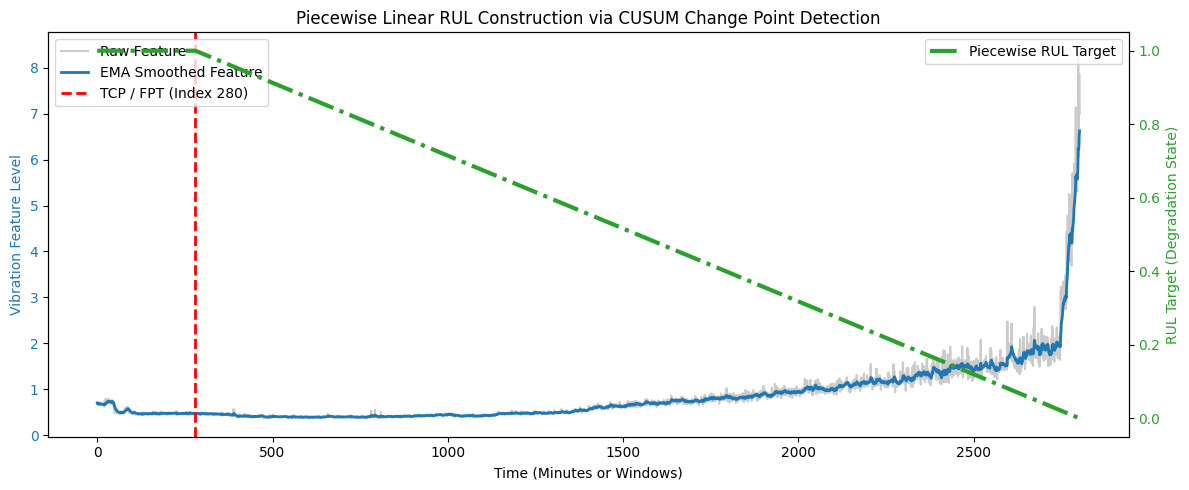

In [ ]:
# Construct piecewise RUL array allocations representing actual dataset targets
cusum_detector = UnivariateCUSUMDetector(baseline_ratio=0.2, k_factor=0.5, h_factor=8.0)

def generate_rul_targets(features_list):
    """Processes piece-wise labels based upon the core RMS parameter (Index 1)."""
    y_target_list = []
    
    for feats in features_list:
        rms_series = feats[:, 1]  # Extracting horizontal RMS value mapping sequences
        rul, tcp, smoothed_rms = cusum_detector.generate_pronostia_piecewise_rul(rms_series, ema_span=EMA_SPAN)
        y_target_list.append(rul)
        
    return y_target_list

print("Generating Piecewise Sequence Ground Truth limits tracking (Training Features)...")
# y_train_list COMPLETELY REPLACES the native target arrays from rul-datasets
y_train_list = generate_rul_targets(X_train_ext_list)

print("Generating Piecewise Sequence Ground Truth limits tracking (Validation Features)...")
y_val_list = generate_rul_targets(X_val_ext_list)

print("Generating Piecewise Sequence Ground Truth limits tracking (Testing Features)...")
y_test_list = generate_rul_targets(X_test_ext_list)

# Render CUSUM plots for ALL Training Bearings to verify Piecewise RUL targets individually
print("Executing Feature Evaluator Testing Process Layout Mapping Check...")
for i, train_feat in enumerate(X_train_ext_list):
    print(f"\n========== Training Bearing {i+1} Target Analysis ==========")
    rms_series = train_feat[:, 1]
    rul_target = y_train_list[i]
    _, tcp_val, smoothed_eval = cusum_detector.generate_pronostia_piecewise_rul(rms_series, ema_span=EMA_SPAN)
    
    cusum_detector.plot_cusum_validation(
        feature_series=rms_series, 
        smoothed_series=smoothed_eval, 
        rul_target=rul_target, 
        tcp_index=tcp_val
    )

## 4. Normalization (Scaling)
To prevent statistical magnitude biases, features are scaled using Min-Max scaling algorithms established uniquely from the Training Set properties. This normalization is executed explicitly prior to feature selection to establish commensurate evaluation metrics limits across unscaled features.

In [7]:
# Aggregate training extractions to fit normalizer
X_train_concat_all = np.concatenate(X_train_ext_list, axis=0)

scaler = StandardScaler()
scaler.fit(X_train_concat_all)

# Routine function representing transformation distributions retaining list format
def scale_features(X_list, scaler):
    return [scaler.transform(X_b) for X_b in X_list]

print("Applying Standard scaling per feature across dataset boundaries...")
X_train_norm_list = scale_features(X_train_ext_list, scaler)
X_val_norm_list = scale_features(X_val_ext_list, scaler)
X_test_norm_list = scale_features(X_test_ext_list, scaler)

print(f"Normalized Master Train Matrix Shape: {X_train_concat_all.shape}")

Applying Standard scaling per feature across dataset boundaries...
Normalized Master Train Matrix Shape: (5897, 124)


## 5. Feature Selection (Spearman & Monotonicity Criteria Check)
Determining robust features correlating chronologically and monotonically regarding progressive linear target targets. Measurements implement scaled matrices yielding generalized evaluations.

In [8]:
print("Computing evaluation criteria on the normalized Train set mapping bearing arrays...")

# Processing criteria per normalized dimensions via local sigma variance adjustments
metrics_df = extractor.calculate_criteria(X_train_norm_list, y_train_list)

# Applying definitive filtering threshold boundaries
selected_features_df = metrics_df[metrics_df['Criteria'] > THRESHOLD_SELECTION]
selected_indices = selected_features_df['Feature_Idx'].values

print(f"Total Optimal Selected Features (> {THRESHOLD_SELECTION}): {len(selected_indices)} / 124")

# Reconcatenation and column dropping routine per defined list architectures
def apply_selection_and_concat(X_list, y_list, sel_idx):
    X_concat = np.concatenate(X_list, axis=0)[:, sel_idx]
    y_concat = np.concatenate(y_list, axis=0)
    return X_concat, y_concat

X_train_final, y_train_concat = apply_selection_and_concat(X_train_norm_list, y_train_list, selected_indices)
X_val_final, y_val_concat = apply_selection_and_concat(X_val_norm_list, y_val_list, selected_indices)
X_test_final, y_test_concat = apply_selection_and_concat(X_test_norm_list, y_test_list, selected_indices)

Computing evaluation criteria on the normalized Train set mapping bearing arrays...
Total Optimal Selected Features (> 0.4): 22 / 124


In [9]:
# Output Detailed Score Identifiers per Selected Feature Array
print("Selected Feature Evaluation Metrics Portfolio:")
for idx, row in selected_features_df.iterrows():
    print(f"Feature {int(row['Feature_Idx'])}: Spearman Correlation = {row['Spearman']:.4f}, Modified Monotonicity Phase = {row['Monotonicity']:.4f}, Mean Criteria = {row['Criteria']:.4f}")

Selected Feature Evaluation Metrics Portfolio:
Feature 0: Spearman Correlation = 0.5296, Modified Monotonicity Phase = 0.3486, Mean Criteria = 0.4391
Feature 2: Spearman Correlation = 0.5138, Modified Monotonicity Phase = 0.6342, Mean Criteria = 0.5740
Feature 3: Spearman Correlation = 0.5591, Modified Monotonicity Phase = 0.2621, Mean Criteria = 0.4106
Feature 7: Spearman Correlation = 0.7190, Modified Monotonicity Phase = 0.2296, Mean Criteria = 0.4743
Feature 10: Spearman Correlation = 0.6020, Modified Monotonicity Phase = 0.2758, Mean Criteria = 0.4389
Feature 12: Spearman Correlation = 0.4429, Modified Monotonicity Phase = 0.4010, Mean Criteria = 0.4220
Feature 14: Spearman Correlation = 0.4908, Modified Monotonicity Phase = 0.4213, Mean Criteria = 0.4561
Feature 21: Spearman Correlation = 0.4989, Modified Monotonicity Phase = 0.4074, Mean Criteria = 0.4531
Feature 22: Spearman Correlation = 0.5242, Modified Monotonicity Phase = 0.3851, Mean Criteria = 0.4546
Feature 25: Spearman 

## 6. Visualization & Evaluation
Showcase selected indices mathematically and visually demonstrate the progression alignment for random sample validations.

Total Selected Features: 22
Selected List:
[np.int64(0), np.int64(2), np.int64(3), np.int64(7), np.int64(10), np.int64(12), np.int64(14), np.int64(21), np.int64(22), np.int64(25), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(38), np.int64(41), np.int64(50), np.int64(62), np.int64(64), np.int64(65), np.int64(72), np.int64(90)]



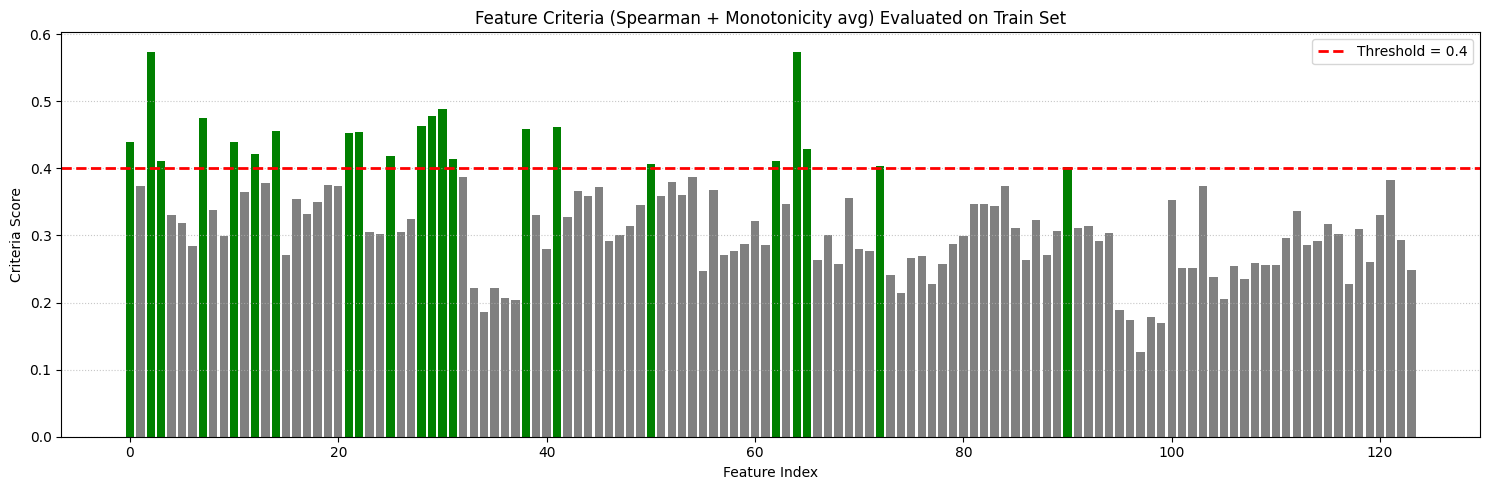

In [10]:
print(f"Total Selected Features: {len(selected_indices)}")
print(f"Selected List:\n{list(selected_indices)}\n")

plt.figure(figsize=(15, 5))
colors = ['green' if cri > THRESHOLD_SELECTION else 'gray' for cri in metrics_df['Criteria']]
plt.bar(metrics_df['Feature_Idx'], metrics_df['Criteria'], color=colors)
plt.axhline(y=THRESHOLD_SELECTION, color='red', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD_SELECTION}')
plt.title("Feature Criteria (Spearman + Monotonicity avg) Evaluated on Train Set")
plt.xlabel("Feature Index")
plt.ylabel("Criteria Score")
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

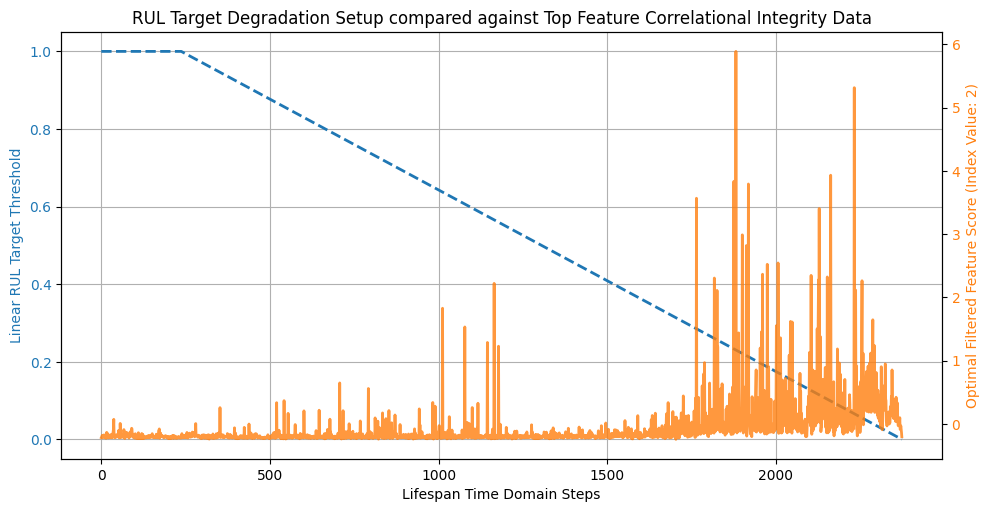

In [ ]:
# Plot Linear RUL Target Curve against optimal extracted criteria
if len(selected_indices) > 0:
    top_feature_global_idx = int(
        selected_features_df.sort_values(by='Criteria', ascending=False).iloc[0]['Feature_Idx']
    )
    
    # Internal localized column referencing representation
    top_feature_pos = list(selected_indices).index(top_feature_global_idx)
    
    cursor = 0
    # Plotting validation results dynamically per every available bearing
    for i, val_target_sample in enumerate(y_val_list):
        plot_limit = len(val_target_sample)
        
        # Slice X_val_final dynamically to get the corresponding feature set for this specific bearing
        val_feature_sample = X_val_final[cursor : cursor + plot_limit, top_feature_pos]
        cursor += plot_limit
        
        fig, ax1 = plt.subplots(figsize=(10, 5))

        color = 'tab:blue'
        ax1.set_xlabel('Lifespan Time Domain Steps')
        ax1.set_ylabel('Piecewise RUL Target', color=color)
        ax1.plot(val_target_sample, color=color, linestyle='--', linewidth=2, label='Degradation Target Setup')
        ax1.tick_params(axis='y', labelcolor=color)

        ax2 = ax1.twinx()  
        color = 'tab:orange'
        ax2.set_ylabel(f'Optimal Filtered Feature Score (Index Value: {top_feature_global_idx})', color=color)  
        ax2.plot(val_feature_sample, color=color, linewidth=2, alpha=0.8, label='Optimal Analyzed Segment')
        ax2.tick_params(axis='y', labelcolor=color)

        fig.tight_layout()  
        plt.title(f"Bearing Validation {i+1}: RUL Target Degradation Setup vs Top Feature Correlational Data")
        ax1.grid(True)
        plt.show()
else:
    print("Optimization Criteria Thresholding unpassed.")

## 7. Save Preprocessed Dataset

Save all preprocessing results to `OUTPUT_DATASET_PATH` so that the modeling notebook can be loaded directly without having to rerun the pipeline from the beginning.

**Files saved:**
- `dataset_train/val/test.npz` — X (features) and y (RUL) arrays
- `bearing_boundaries.npz` — start/end index of each bearing in the concat array
- `scaler.pkl` — MinMaxScaler fitted to train
- `selected_feature_indices.npy` — indices for 91 selected features out of 124
- `preprocessing_metadata.json` — complete configuration file + leakage audit

In [ ]:
os.makedirs(OUTPUT_DATASET_PATH, exist_ok=True)

# ---------------------------------------------------------------
# 1. Output Compressions: Target Independent Formats
# ---------------------------------------------------------------
np.savez_compressed(
    os.path.join(OUTPUT_DATASET_PATH, "dataset_train.npz"),
    X=X_train_final, y=y_train_concat
)
np.savez_compressed(
    os.path.join(OUTPUT_DATASET_PATH, "dataset_val.npz"),
    X=X_val_final, y=y_val_concat
)
np.savez_compressed(
    os.path.join(OUTPUT_DATASET_PATH, "dataset_test.npz"),
    X=X_test_final, y=y_test_concat
)
print("Persisted Model Input Representations:")
print(f"  Training Sets: Features Dimensionality = {X_train_final.shape}, Targets = {y_train_concat.shape}")
print(f"  Validation Sets: Features Dimensionality = {X_val_final.shape}, Targets = {y_val_concat.shape}")
print(f"  Testing Sets: Features Dimensionality = {X_test_final.shape}, Targets = {y_test_concat.shape}")

# ---------------------------------------------------------------
# 2. Extract Subsystem Bearing Partitions (Separation Metadata)
# ---------------------------------------------------------------
def compute_boundaries(y_list):
    bounds, cursor = [], 0
    for y_b in y_list:
        n = len(y_b)
        bounds.append((cursor, cursor + n))
        cursor += n
    return bounds

np.savez_compressed(
    os.path.join(OUTPUT_DATASET_PATH, "bearing_boundaries.npz"),
    train = np.array(compute_boundaries(y_train_list)),
    val   = np.array(compute_boundaries(y_val_list)),
    test  = np.array(compute_boundaries(y_test_list))
)
print("\nPersisted 'bearing_boundaries.npz'")
print(f"  Train: Compiled from {len(y_train_list)} bearings")
print(f"  Val: Compiled from {len(y_val_list)} bearings")
print(f"  Test: Compiled from {len(y_test_list)} bearings")

# ---------------------------------------------------------------
# 3. Model State Persistency (StandardScaler Dump)
# ---------------------------------------------------------------
joblib.dump(scaler, os.path.join(OUTPUT_DATASET_PATH, "scaler.pkl"))
print("\nPersisted 'scaler.pkl' (StandardScaler fitted securely on pure pre-selection training array configurations)")

# ---------------------------------------------------------------
# 4. Independent Selected Reference Indices Persistence
# ---------------------------------------------------------------
np.save(
    os.path.join(OUTPUT_DATASET_PATH, "selected_feature_indices.npy"),
    selected_indices
)
print(f"\nPersisted 'selected_feature_indices.npy': Filtering complete with {len(selected_indices)} optimally scored matrices passed")

# ---------------------------------------------------------------
# 5. Metadata JSON (Reproduction Blueprint Configuration Checklists)
# ---------------------------------------------------------------
metadata = {
    "dataset": "PRONOSTIA/FEMTO",
    "conditions_used": [1, 2, 3],
    "window_size": WINDOW_SIZE,
    "n_features_extracted": 124,
    "n_features_selected": int(len(selected_indices)),
    "selected_feature_indices": selected_indices.tolist(),
    "threshold_selection": THRESHOLD_SELECTION,
    "rul_normalization": "norm_rul=False (Overridden custom CUSUM generated Piecewise sequence limits from 1.0 to 0.0)",
    "scaler_type": "MinMaxScaler(feature_range=(0, 1)) configured completely pre-feature-selection array layouts",
    "feature_selection_basis": "Integrated criterion representing Mean ModMonotonicity & Spearman rank correlations. Calculated mathematically per bearing scope via standardized train lists mapping values",
    "split": {
        "train_n_bearings": len(y_train_list),
        "val_n_bearings"  : len(y_val_list),
        "test_n_bearings" : len(y_test_list),
        "train_total_samples": int(X_train_final.shape[0]),
        "val_total_samples"  : int(X_val_final.shape[0]),
        "test_total_samples" : int(X_test_final.shape[0]),
    },
    "leakage_audit": {
        "scaler_fit"        : "Constructed utilizing solely fundamental train subset constraints prior to evaluation criteria application checks. (No feature leakage)",
        "feature_selection": "Applied evaluations only to properly bounded standardized array sequences. (No analytical leakage)",
        "val_test_role"     : "Utilized purely as un-analyzed transformable references generating standardized formats retaining zero impact upon evaluation or boundary selection criteria outputs."
    },
    "created_at": datetime.now().isoformat()
}
with open(os.path.join(OUTPUT_DATASET_PATH, "preprocessing_metadata.json"), 'w') as _f:
    _json.dump(metadata, _f, indent=2)
print("\nPersisted 'preprocessing_metadata.json' tracking records")

# ---------------------------------------------------------------
# Conclusion Log Details Checkout Form
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("PIPELINE EXECUTION COMPLETE & PREPROCESSING FINALIZED")
print("Target Master Output Framework Routing Architecture:", OUTPUT_DATASET_PATH)
print("=" * 60)
summary = [
    ("dataset_train.npz",             f"Target Vector Arrays: Sequence Input Shape = {X_train_final.shape}, Base Value Results = {y_train_concat.shape}"),
    ("dataset_val.npz",               f"Target Vector Arrays: Sequence Input Shape = {X_val_final.shape}, Base Value Results = {y_val_concat.shape}"),
    ("dataset_test.npz",              f"Target Vector Arrays: Sequence Input Shape = {X_test_final.shape}, Base Value Results = {y_test_concat.shape}"),
    ("bearing_boundaries.npz",        f"Bearing Origin Indices Compilation Lists Representing Train Count ({len(y_train_list)}), Val Count ({len(y_val_list)}), Test Count ({len(y_test_list)})"),
    ("scaler.pkl",                    "Extracted Representation StandardScaler Algorithm Mapping Bounds"),
    ("selected_feature_indices.npy",  f"Extracted Int Values Identifications Defining Final Features Count: {len(selected_indices)}"),
    ("preprocessing_metadata.json",   "System Logging Extracted Reproducibility Tracked Properties Schema Matrix"),
]
for fname, desc in summary:
    print(f"  {fname:<38} {desc}")

print("\nModeling System Data Ingestion Commands Instruction:")
print("  data = np.load('dataset_train.npz')")
print("  X_train, y_train = data['X'], data['y']")
print("  scaler = joblib.load('scaler.pkl')")
print("  bounds = np.load('bearing_boundaries.npz')")
print("  # Specific Slicing Application Call Protocol Representation Details Slices Target Train Limits: s, e = bounds['train'][i]; X_b = X_train[s:e]")

Persisted Model Input Representations:
  Training Sets: Features Dimensionality = (5897, 22), Targets = (5897,)
  Validation Sets: Features Dimensionality = (5967, 22), Targets = (5967,)
  Testing Sets: Features Dimensionality = (13025, 22), Targets = (13025,)

Persisted 'bearing_boundaries.npz'
  Train: Compiled from 5 bearings
  Val: Compiled from 3 bearings
  Test: Compiled from 9 bearings

Persisted 'scaler.pkl' (StandardScaler fitted securely on pure pre-selection training array configurations)

Persisted 'selected_feature_indices.npy': Filtering complete with 22 optimally scored matrices passed

Persisted 'preprocessing_metadata.json' tracking records

PIPELINE EXECUTION COMPLETE & PREPROCESSING FINALIZED
Target Master Output Framework Routing Architecture: D:\Proyek Dosen\Riset Bearing\Processed_Dataset\FEMTO
  dataset_train.npz                      Target Vector Arrays: Sequence Input Shape = (5897, 22), Base Value Results = (5897,)
  dataset_val.npz                        Targ